# ShallowLandslider: Quick-start Notebook

This notebook runs a small, reproducible `ShallowLandslider` model with Newmark displacement and runout enabled. It saves the same self-describing run directory used by `ShallowLandslider_output_analysis.ipynb`, so the analysis notebook can be run immediately afterwards.

To create a compatible environment, and install all deps:
```bash
conda env create -f environment.yml
conda activate shallow_landslider
```


## Prerequisites

- Python 3.9+ recommended
- Packages: `numpy`$\geq$ 2.0, `matplotlib`, `pandas`, `landlab`, `scipy`, `scikit-image`, `richdem`, `seaborn`, 
- Local modules available on your path: `components.shallow_landslider`, and `utils` providing:
  - `get_topo`, `apply_soil_depth`, `calculate_terrain_attribute`, `generate_acceleration_grid`,
  - `pickle_or_not_to_pickle` (if using measured data)

> If running in a clean environment, install deps, e.g.:
```bash
pip install landlab numpy pandas matplotlib scipy scikit-image seaborn richdem
```

> Ensure the working directory contains your component and helper modules, or update `sys.path` accordingly.
> The component has been tested on RasterModelGrid **only**; it might not work with other types of grids

## Imports & Settings

In [1]:
# Standard imports
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from landlab import RasterModelGrid, imshowhs_grid
from landlab.components import PriorityFloodFlowRouter

# Project modules
from components.shallow_landslider import ShallowLandslider

# Utilities to help quick-start
from utils import (
    apply_soil_depth,
    calculate_terrain_attribute,
    generate_acceleration_grid,
    get_topo,
    pickle_or_not_to_pickle,
    plot_comparison_panels_with_ecdf,
    save_model_run,
    setup_logger,
)

# Plotting aesthetics
plt.style.use("seaborn-v0_8")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.grid": False,
    }
)

## Configuration 1 (edit these for your study area)

In [5]:
# DEM & flow settings
config = {
    'dem_info': {
        'region': 'nepal',  # 'nepal', 'png', 'nz', 'japan'
        'dem_type': 'SRTMGL1',
        'buffer': 0.01,
        'smooth_num': 0,
        'plot_dem': True,
        # Use a bundled DEM by default so the public notebook runs without network access.
        'use_local_dem': True,
        'local_dem_path': './input_data/dem/SRTMGL1_28.169999999999998_85.03_28.3_85.21000000000001.asc',
        # Optional: set OPENTOPOGRAPHY_API_KEY in your environment to download a fresh DEM.
        'api_key': os.environ.get('OPENTOPOGRAPHY_API_KEY'),
        # Bounding box used only when use_local_dem=False.
        'north': 28.29,
        'east': 85.20,
        'south': 28.18,
        'west': 85.04,
    },
    'flow_params': {
        'flow_metric': 'D8',
        'separate_hill_flow': True,  # Required for optional runout; creates hill-flow receiver fields
        'hill_flow_metric': 'Quinn', # Multiflow proportions split sediment among paths
        'depression_handling': 'fill',
        'update_hill_depressions': True,
        'accumulate_flow': True,
    },
    'soil_params': {  # Edit these soil properties
        'angle_int_frict': 30,      # degrees
        'cohesion_eff': 15e3,       # Pa
        'submerged_soil_proportion': 0.5,
        'max_soil_depth': 1.5,      # m
        'plot_soil': False,
        'distribution': 'curvature', # 'uniform'|'elevation'|'drainage_area'|'curvature'|'mean_elev_curv'
        'relationship': 'linear_std_local',
        'decay_rate': 1.0,
        'exponent': 2.0,
        'drainage_transform': 'threshold',
        'drainage_threshold': 1e6,
        'drainage_power': 0.3,
        'P0': 0.05,
        'h_star': 1.0,
        'D': 0.01,
        'h_min': 0.1,
        'h_no_ss': 0.0,
    },
    'pga': {
        'horizontal_max': 0.6,
        'vertical_max': 0.2,
        'distribution': 'uniform', # 'uniform', 'circular', 'square', 'diamond', or 'exponential'
        'plot_grids': False,
    },
    'simulation': {
        'time_shaking': 5,  # seconds; limits path length in this small example
        'displacement_threshold': 0.0,
        'aspect_interval': 20,
        'random_seed': 5000,
        'handle_small_regions': 'merge',
        'selection_method': 'probabilistic', # or 'pga_weighted'
        'proportion_method': 'conservative',
        'custom_proportion': 0.15,
        'compute_displacement': True, # Required for Newmark displacement and optional runout
        'enable_runout': True,        # The quick start demonstrates runout by default
        'update_soil': True,          # Runout modifies soil__depth in place
    },
    'output': {
        'verbose': False,
        'save_plots': False,
        'output_dir': './runs',       # Read by ShallowLandslider_output_analysis.ipynb
        'save_analysis_bundle': True,
        'save_pickle': False,
    },
    'outputs': {
        'write_parquet': False,       # CSV keeps the quick start dependency-light
        'write_zarr': False,          # .npy rasters are lazy-loadable by the analysis notebook
        'write_npy_fallback': True,
    },
    'quick_start': {
        'crop_shape': None, #(80, 80),       # Set to None to use the complete bundled DEM
        'use_measured_kde': True,    # Faster; enable for KDE-guided region splitting
    },
}


## Load measured landslide data for KDE‑guided splitting
- pickle_or_not_to_pickle bundles all of the input measured data for quick access, and allows the model to pick up the required KDE data for splitting later.
    - Once a pickle has been made with a certain name (e.g., 'measured_data.pkl'), the function will pick it up and open it directly. This process takes milliseconds.
    - If you want to change this, just change the name of the pickle in the pickle_path argument below.
- The pointers need to be pointed towards the files containing the data. Currently they point towards example data from Nepal to run this notebook.

### Datasets available
1. Nepal:
    - file1: "./input_data/nepal/measuredLandslides_all.csv", # All mapped landslides in region, with area, length_m, and width_m fields
    - file2: "./input_data/nepal/measuredLandslides_all_spatialStats.csv", # Zonal stats for all measured landslides
    - Spatial range:
        - Latitude: 27.6N - 28.4N
        - Longitude: 84.5E - 86.2E
2. New Zealand:
    - file1: "./input_data/nz/measuredLandslides_all.csv", # All mapped landslides in region, with area, length_m, and width_m fields
    - file2: "./input_data/nz/measuredLandslides_all_spatialStats.csv", # Zonal stats for all measured landslides
    - Spatial range:
        - Latitudes: (-41.7)N - (-43.1)N
        - Longitudes: 172.22E - 173.9E
3. Papua New Guinea:
    - file1: "./input_data/png/measuredLandslides_all.csv", # All mapped landslides in region, with area, length_m, and width_m fields
    - file2: "./input_data/png/measuredLandslides_all_spatialStats.csv", # Zonal stats for all measured landslides
    - Spatial range:
        - Latitudes: (-5.8)N - (-6.32)N
        - Longitudes: 142.2E - 143.4E
4. Japan:
    - file1: "./input_data/japan/measuredLandslides_all.csv", # All mapped landslides in region, with area, length_m, and width_m fields
    - file2: "./input_data/japan/measuredLandslides_all_spatialStats.csv", # Zonal stats for all measured landslides
    - Spatial range:
        - Latitudes: 38.82N - 39.19N
        - Longitudes: 140.7E - 140.95E

In [6]:
# To choose which dataset to work with, select the region below.
# The default Nepal example uses the bundled DEM path above and does not need network access.
config['dem_info']['region'] = 'nepal'  # 'nepal', 'png', 'nz', 'japan'

# These lat-long bounds are used only when config['dem_info']['use_local_dem'] = False.
config['dem_info']['north'] = 28.29
config['dem_info']['east'] = 85.20
config['dem_info']['south'] = 28.18
config['dem_info']['west'] = 85.04


### Set up file paths, etc. for input and output

In [7]:
# Dictionary of directory paths for each region
region_paths = {
    "nepal":  "./input_data/nepal",
    "png":  "./input_data/png/",
    "nz": "./input_data/nz/",
    "japan": "./input_data/japan/"
}
region = config['dem_info']['region']
if region not in region_paths:
    raise ValueError(f"Unknown region '{region}'. Valid options: {list(region_paths.keys())}")

file_name_dict = {
    "file1": os.path.join(region_paths[region], "measuredLandslides_all.csv"),
    "file2": os.path.join(region_paths[region], "measuredLandslides_all_ZonalStats.csv")
}

pickle_path = os.path.join(region_paths[region], "measured_data.pkl")
config['dem_path'] = config['dem_info']['local_dem_path']
config['random_seed'] = config['simulation']['random_seed']

print("Loaded paths for region:", region)

kde_dict = None
bundle = pickle_or_not_to_pickle(file_name_dict=file_name_dict,
                                    pickle_path=pickle_path, verbose=True)
if config['quick_start']['use_measured_kde']:
    kde_dict = {
        'kde_data': bundle.get('kde_data'),
        'kde_transform': bundle.get('kde_transform'),
    }

logger = setup_logger(
        name="landslider",
        log_dir=config['output']['output_dir'],
        level=config.get("log_level", "INFO"),
        to_console=False,
    )
logger.info("=== Shallow Landslider Run Started ===")
logger.info(f"Using config: {config}")

print('Loaded measured inventory; KDE splitting:', kde_dict is not None)

Loaded paths for region: nepal
Loading preprocessed data from ./input_data/nepal/measured_data.pkl...
Loaded measured inventory; KDE splitting: True


## Build Landlab grid, route flow, and derive terrain attributes
- Uses get_topo() and bmi-topography to download and set up a DEM from OpenTopo for you to help quickly set up a grid. If you have your own grid, set it up here.
- apply_soil_depth() helps set up a simulated soil depth distribution
    - Using a curvature-based distribution here requires richdem and calculate_terrain_attribute()
- If these already exist, you can skip the next several cells

In [8]:
# Get DEM and build grid
dem_info = config['dem_info']

if dem_info.get('use_local_dem', True):
    local_dem_path = Path(dem_info['local_dem_path'])
    if not local_dem_path.exists():
        raise FileNotFoundError(f"Bundled DEM not found: {local_dem_path}")
    mg, z, _ = get_topo(
        buffer=dem_info['buffer'],
        dem_type=dem_info['dem_type'],
        smooth_num=dem_info['smooth_num'],
        load_dem=str(local_dem_path),
    )
else:
    if not dem_info.get('api_key'):
        raise RuntimeError(
            "Set OPENTOPOGRAPHY_API_KEY or switch config['dem_info']['use_local_dem'] to True."
        )
    mg, z, _ = get_topo(
        dem_type=dem_info['dem_type'],
        north=dem_info['north'],
        south=dem_info['south'],
        east=dem_info['east'],
        west=dem_info['west'],
        buffer=dem_info['buffer'],
        smooth_num=dem_info['smooth_num'],
        api_key=dem_info['api_key'],
    )

crop_shape = config['quick_start']['crop_shape']
if crop_shape is not None:
    crop_rows, crop_cols = crop_shape
    if crop_rows > mg.shape[0] or crop_cols > mg.shape[1]:
        raise ValueError(f'crop_shape {crop_shape} exceeds DEM shape {mg.shape}')
    row0 = (mg.shape[0] - crop_rows) // 2
    col0 = (mg.shape[1] - crop_cols) // 2
    cropped_z = mg.at_node['topographic__elevation'].reshape(mg.shape)[
        row0:row0 + crop_rows, col0:col0 + crop_cols
    ].copy()
    lower_left = (
        mg.node_x.reshape(mg.shape)[row0, col0],
        mg.node_y.reshape(mg.shape)[row0, col0],
    )
    mg = RasterModelGrid(crop_shape, xy_spacing=(mg.dx, mg.dy), xy_of_lower_left=lower_left)
    mg.add_field('topographic__elevation', cropped_z.ravel(), at='node')
    # Keep the default fixed-value edges open so depression filling has an outlet.
    z = mg.at_node['topographic__elevation']

logger.info("Loaded DEM")
print(f"Grid loaded: {mg.shape[0]} rows x {mg.shape[1]} cols, {mg.number_of_nodes:,} nodes")


Grid loaded: 468 rows x 648 cols, 303,264 nodes


### Flow routing
- Fills in any voids in the DEM.
- Calculates upstream drainage area (Can be avoided, only required for drainage area-based soil depth)
- How much time this takes strongly depends on the size of the grid

In [9]:
pf = PriorityFloodFlowRouter(
    grid=mg,
    flow_metric=config['flow_params']['flow_metric'],
    separate_hill_flow=config['flow_params']['separate_hill_flow'],
    hill_flow_metric=config['flow_params']['hill_flow_metric'],
    depression_handler=config['flow_params']['depression_handling'],
    update_hill_depressions=config['flow_params']['update_hill_depressions'],
    accumulate_flow=config['flow_params']['accumulate_flow'],
)
pf.run_one_step()
logger.info("Flow routing complete")

### Calculate planform curvature

In [10]:
# Terrain attribute example: planform curvature (for curvature‑based soil depth using richdem)
curv = calculate_terrain_attribute(
    grid=mg, field_name='topographic__elevation', attrib='planform_curvature'
)
logger.info("Planform curvature calculated")


A Planform curvature attribute calculation
C Zevenbergen, L.W., Thorne, C.R., 1987. Quantitative analysis of land surface topography. Earth surface processes and landforms 12, 47–56.

t Wall-time = 0.00151821


### Add soil depth
- Also adds bedrock__elevation field to grid (also optional)

In [11]:
if 'soil__depth' not in mg.at_node:
    soil_depth = mg.add_zeros('soil__depth', at='node')

soil_depth = apply_soil_depth(
    grid=mg,
    max_soil_depth=config['soil_params']['max_soil_depth'],
    distribution=config['soil_params']['distribution'],
    relationship=config['soil_params']['relationship'],
    decay_rate=config['soil_params']['decay_rate'],
    exponent=config['soil_params']['exponent'],
    drainage_transform=config['soil_params']['drainage_transform'],
    drainage_threshold=config['soil_params']['drainage_threshold'],
    drainage_power=config['soil_params']['drainage_power'],
    P0=config['soil_params']['P0'],
    h_star=config['soil_params']['h_star'],
    D=config['soil_params']['D'],
    h_min=config['soil_params']['h_min'],
    h_no_ss=config['soil_params']['h_no_ss'],
    plot=config['soil_params']['plot_soil'],
)

# Bedrock elevation from DEM minus soil thickness
if 'bedrock__elevation' not in mg.at_node:
    mg.add_zeros('bedrock__elevation', at='node', clobber=True)
mg.at_node['bedrock__elevation'][:] = mg.at_node['topographic__elevation'] - mg.at_node['soil__depth']

print(f"Applied {config['soil_params']['distribution']}-based soil depth distribution")

logger.info(f"Applied {config['soil_params']['distribution']} soil depth distribution")

/Users/sghoshal/Developer/landlab/src/landlab/field/graph_field.py:1347: FutureWarning: Calling `add_empty` with the field location as the first argument is deprecated and will be removed in future versions. Instead, please use the `at` keyword to specify the location: add_empty(arg0, at='node').
  data = self.add_empty(*args, **kwds)

A Planform curvature attribute calculation
C Zevenbergen, L.W., Thorne, C.R., 1987. Quantitative analysis of land surface topography. Earth surface processes and landforms 12, 47–56.

t Wall-time = 0.000873708


Applied curvature-based soil depth distribution


### Calculate slopes and topographic aspect

In [12]:
slopes_rad = mg.calc_slope_at_node(elevs='topographic__elevation')
slopes_deg = np.degrees(slopes_rad)
aspect_nodes = np.array(mg.calc_aspect_at_node(elevs='topographic__elevation',
                                                unit='degrees', ignore_closed_nodes=True))
aspect_nodes[mg.boundary_nodes] = np.nan
logger.info("Calculated slopes and aspect")

## Generate earthquake PGA grids
- Quickly sets up arrays for PGA_h and PGA_v using parameters set up above
- These can be "uniform", "circular", "square", "diamond", or "exponential" to test various patterns
- Can also be skipped if you have existing arrays of the same size as the grid

In [13]:
pga_h, pga_v = generate_acceleration_grid(
    grid=mg,
    horizontal_max=config['pga']['horizontal_max'],
    vertical_max=config['pga']['vertical_max'],
    distribution=config['pga']['distribution'],
    plot_grids=config['pga']['plot_grids'],
)
logger.info("Created earthquake PGA arrays")

uniform horizontal and vertical PGA arrays generated


## Initialise and run the ShallowLandslider component
- Parameters taken from dictionary at the top of the notebook
- Runout is enabled in the default configuration.
- Each run is saved below `runs/` in the format consumed by the output-analysis notebook.

In [14]:
# Initialise component
ls = ShallowLandslider(
    grid=mg,
    cohesion_eff=config['soil_params']['cohesion_eff'],
    angle_int_frict=config['soil_params']['angle_int_frict'],
    submerged_soil_proportion=config['soil_params']['submerged_soil_proportion'],
    pga_h=pga_h,
    pga_v=pga_v,
    pga_h_max=config['pga']['horizontal_max'],
    pga_v_max=config['pga']['vertical_max'],
    selection_method=config['simulation']['selection_method'],
    proportion_method=config['simulation']['proportion_method'],
    custom_proportion=config['simulation']['custom_proportion'],
    random_seed=config['simulation']['random_seed'],
    aspect_interval=config['simulation']['aspect_interval'],
    compute_displacement=config['simulation']['compute_displacement'],
    time_shaking=config['simulation']['time_shaking'],
    displacement_threshold=config['simulation']['displacement_threshold'],
    enable_runout=config['simulation']["enable_runout"],
    update_soil=config['simulation']["update_soil"],
    g=9.81,
    split_by_width_config=(None if kde_dict is None else {
        'kde_data': kde_dict.get('kde_data'),
        'kde_transform': kde_dict.get('kde_transform'),
        'convergence_threshold': 0.75,
        'min_region_size': 10,
        'max_iterations': 10,
        'width_threshold': 1.5,
    }),
    verbose=config['output']['verbose'],
)

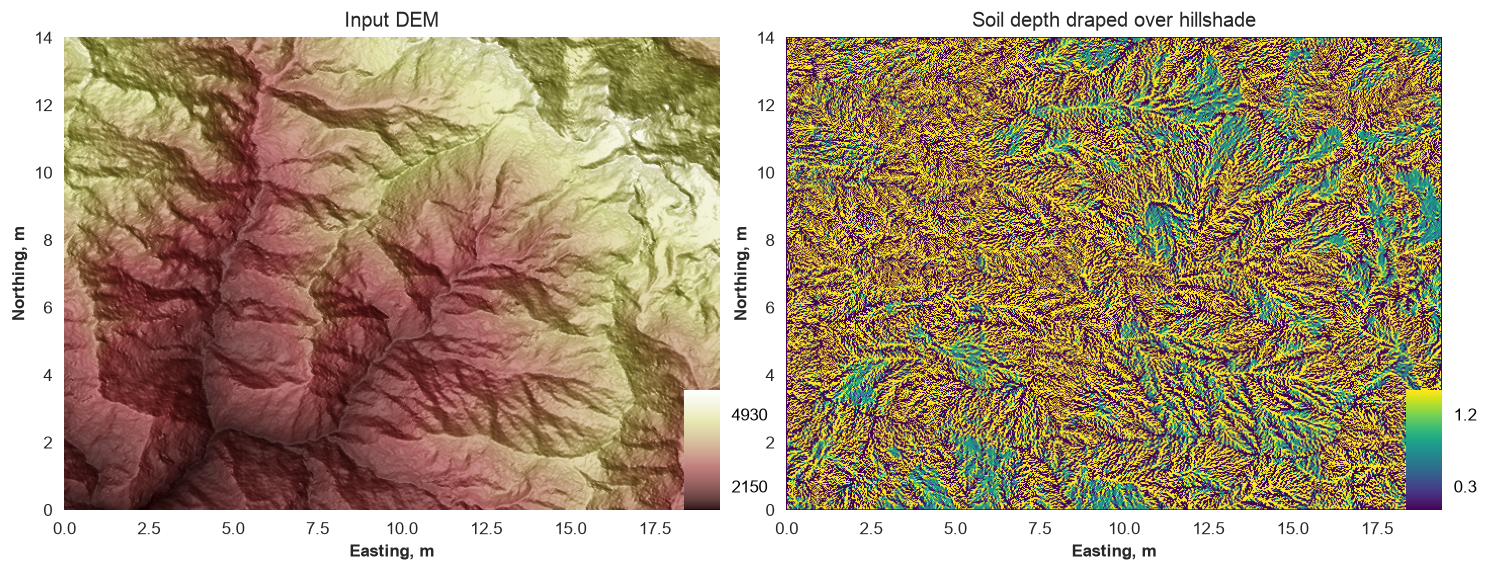

In [15]:
fig, axes = plt.subplots(1, 2, layout='constrained', figsize=(12, 5))
plt.sca(axes[0])
imshowhs_grid(
    ls.grid,
    'topographic__elevation',
    plot_type='DEM',
    allow_colorbar=True,
    cbar_or='vertical',
    ticks_km=True,
    cbar_loc='lower right',
    cbar_height=1.0,
    cbar_width=0.3,
)
axes[0].set_title('Input DEM')

plt.sca(axes[1])
imshowhs_grid(
    ls.grid,
    'topographic__elevation',
    plot_type='Drape1',
    drape1=np.ma.masked_invalid(ls.grid.at_node['soil__depth']),
    cmap='viridis',
    allow_colorbar=True,
    cbar_or='vertical',
    ticks_km=True,
    cbar_loc='lower right',
    cbar_height=1.0,
    cbar_width=0.3,
)
axes[1].set_title('Soil depth draped over hillshade')

plt.show()


In [16]:
# Run component
soil_depth_before_landsliding = mg.at_node['soil__depth'].copy()
ls.run_one_step()

run_dir = None
if config['output']['save_analysis_bundle']:
    run_dir = save_model_run(
        save_pickle=config['output']['save_pickle'],
        ls=ls,
        config=config,
        output_dir=config['output']['output_dir'],
        logger=logger,
        runtime_metadata={'execution_mode': 'quick_start', 'crop_shape': list(mg.shape)},
    )
    print(f'Saved analysis-ready run: {run_dir}')

props = ls.results.get('group_properties')
if props is None or len(props) == 0:
    raise RuntimeError('No group properties table was computed.')

props_filtered = props.loc[props['selected']].copy()
measured_spatial_stats_900greater = bundle.get('measured_spatial_stats_900greater')
labels = mg.at_node['landslide__selected_labels'].copy().reshape(mg.shape)
labels_masked = np.ma.masked_where(labels == 0, labels)

summary = {
    'candidate_groups': int(len(props)),
    'selected_groups': int(len(props_filtered)),
    'selected_nodes': int(np.count_nonzero(mg.at_node['landslide__selected_labels'] > 0)),
    'unstable_nodes': int(np.count_nonzero(mg.at_node['landslide__unstable_mask'])),
}
if 'landslide__newmark_displacement' in mg.at_node:
    disp = mg.at_node['landslide__newmark_displacement']
    valid_disp = disp[np.isfinite(disp) & (disp > 0)]
    summary['positive_displacement_nodes'] = int(valid_disp.size)
    summary['median_positive_displacement_m'] = float(np.median(valid_disp)) if valid_disp.size else 0.0

print('Run summary')
for key, value in summary.items():
    print(f'  {key}: {value}')

props_filtered.head()


/Users/sghoshal/Developer/EQShallowLandslider/components/shallow_landslider/shallow_landslide_component.py:1346: FutureWarning: `RegionProperties.major_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_major_length` instead. 
  getattr(r, "major_axis_length", 0.0) * self.grid.dx
/Users/sghoshal/Developer/EQShallowLandslider/components/shallow_landslider/shallow_landslide_component.py:1349: FutureWarning: `RegionProperties.minor_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_minor_length` instead. 
  getattr(r, "minor_axis_length", 0.0) * self.grid.dx


Saved analysis-ready run: runs/20260804T102405585485Z_SL_c15000_phi30_sub50_curvature-linear_std_local_probabilistic_seed5000
Run summary
  candidate_groups: 40169
  selected_groups: 6026
  selected_nodes: 19703
  unstable_nodes: 121554
  positive_displacement_nodes: 19703
  median_positive_displacement_m: 47.260868752714266


,max_elevation,median_elevation,area,slope_direction_length_new,perpendicular_width_new,local_relief,median_slope,mean_aspect,selected
label,,,,,,,,,
25,1509.0,1475.0,3600.0,60.000000,30.000000,52.0,40.991341,91.665975,True
28,2794.0,2776.5,1800.0,30.000000,0.000000,35.0,46.582027,1.763147,True
56,2229.0,2167.0,6300.0,123.693169,43.656413,102.0,35.547409,17.031191,True
62,2651.0,2616.0,3600.0,67.082039,26.832816,58.0,42.139603,7.080177,True
89,3180.0,3128.0,7200.0,98.639392,64.115605,101.0,44.235809,60.283112,True


## Runout diagnostics

Runout redistributes failed soil downslope after Newmark displacement is computed. The default quick-start configuration enables it and saves erosion, deposition, net soil-depth change, and final soil depth as analysis-ready rasters.

To disable runout, set both `enable_runout` and `update_soil` to `False` in the configuration cell.


In [17]:
runout_diagnostics = None

if config['simulation']['enable_runout'] and config['simulation']['update_soil']:
    runout_diagnostics = {
        'erosion': mg.at_node['landslide__erosion'].copy(),
        'deposition': mg.at_node['landslide__deposition'].copy(),
        'soil_change': mg.at_node['landslide__soil_depth_change'].copy(),
    }
else:
    print('Runout is disabled for this run.')

if runout_diagnostics is not None:
    print(f"Nodes with changed soil depth: {np.count_nonzero(np.abs(runout_diagnostics['soil_change']) > 0):,}")
    print(f"Total erosion: {np.sum(runout_diagnostics['erosion']):.6g} m-node")
    print(f"Total deposition: {np.sum(runout_diagnostics['deposition']):.6g} m-node")


Nodes with changed soil depth: 77,936
Total erosion: 29107.6 m-node
Total deposition: 29107.6 m-node


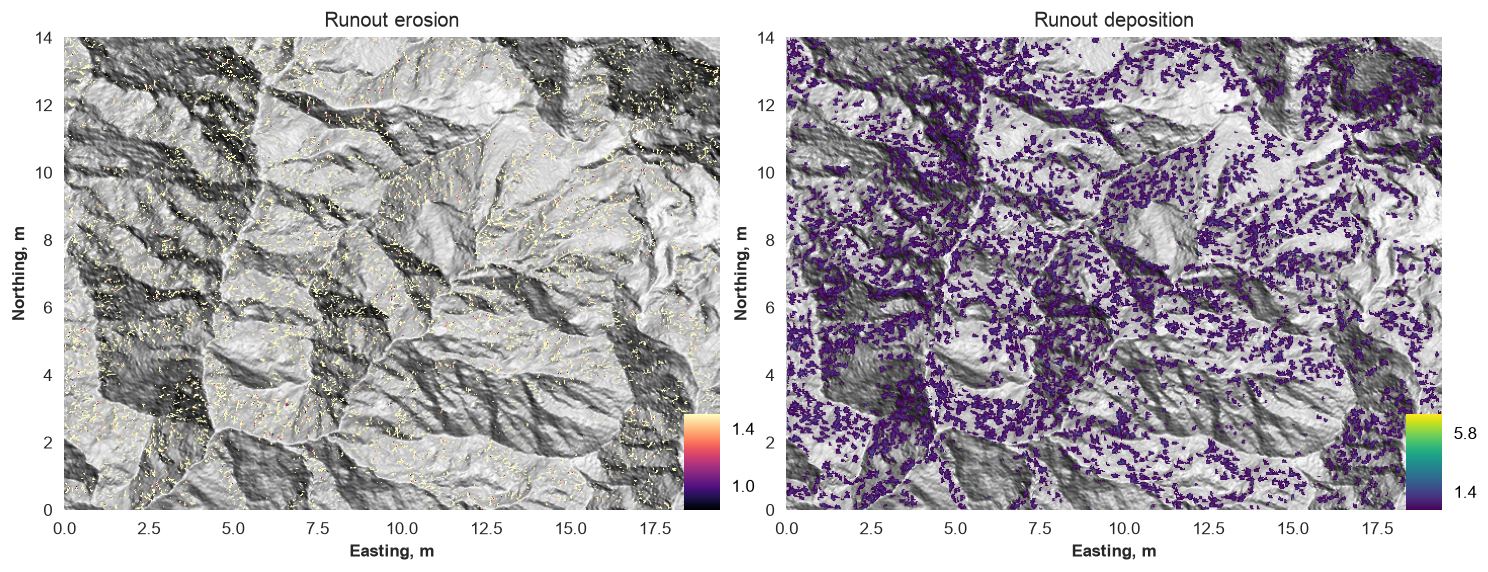

In [18]:
if runout_diagnostics is None:
    print('Runout diagnostics are not available. Enable runout in the configuration cell.')
else:
    fig, axes = plt.subplots(1, 2, layout='constrained', figsize=(12, 5))

    plt.sca(axes[0])
    imshowhs_grid(
        mg,
        'topographic__elevation',
        plot_type='Drape1',
        drape1=np.ma.masked_equal(runout_diagnostics['erosion'], 0),
        cmap='magma',
        allow_colorbar=True,
        cbar_or='vertical',
        ticks_km=True,
        cbar_loc='lower right',
        cbar_height=0.8,
        cbar_width=0.3,
    )
    axes[0].set_title('Runout erosion')

    plt.sca(axes[1])
    imshowhs_grid(
        mg,
        'topographic__elevation',
        plot_type='Drape1',
        drape1=np.ma.masked_equal(runout_diagnostics['deposition'], 0),
        cmap='viridis',
        allow_colorbar=True,
        cbar_or='vertical',
        ticks_km=True,
        cbar_loc='lower right',
        cbar_height=0.8,
        cbar_width=0.3,
    )
    axes[1].set_title('Runout deposition')

    plt.show()


In [19]:
fig, axes = plt.subplots(1, 3, layout='constrained', figsize=(15, 5))

plt.sca(axes[0])
imshowhs_grid(
    mg,
    'topographic__elevation',
    plot_type='Drape1',
    drape1=labels_masked,
    cmap='tab20',
    allow_colorbar=False,
    ticks_km=True,
)
axes[0].set_title('Selected landslide labels')

plt.sca(axes[1])
imshowhs_grid(
    mg,
    'topographic__elevation',
    plot_type='Drape1',
    drape1=np.ma.masked_invalid(mg.at_node['landslide__factor_of_safety']),
    cmap='magma_r',
    allow_colorbar=True,
    cbar_or='vertical',
    ticks_km=True,
    cbar_loc='lower right',
    cbar_height=0.8,
    cbar_width=0.3,
)
axes[1].set_title('Factor of safety')

plt.sca(axes[2])
if 'landslide__newmark_displacement' in mg.at_node:
    displacement = np.ma.masked_less_equal(mg.at_node['landslide__newmark_displacement'], 0)
    imshowhs_grid(
        mg,
        'topographic__elevation',
        plot_type='Drape1',
        drape1=displacement,
        cmap='plasma',
        allow_colorbar=True,
        cbar_or='vertical',
        ticks_km=True,
        cbar_loc='lower right',
        cbar_height=0.8,
        cbar_width=0.3,
    )
    axes[2].set_title('Positive Newmark displacement')
else:
    axes[2].text(0.5, 0.5, 'Displacement disabled', ha='center', va='center')
    axes[2].set_axis_off()

plt.show()


ValueError: cannot convert float NaN to integer

<Figure size 1800x600 with 5 Axes>

## Publication-ready output figures

The following cells provide a compact set of outputs suitable for a public quickstart: selected landslide maps, stability and displacement fields, and observed-vs-modelled distributions for area, elevation, and slope.


## Visualise simulated landslides
- Plots a figure with four panels:
    1. Simulated landslides draped over hillshade
    2. Histogram and ecdf of landslide area (mapped vs. simulated)
    3. Histogram and ecdf of mean landslide elevations (mapped vs. simulated)
    4. Histogram and ecdf of mean landslide slopes (mapped vs. simulated)
- *Only* compares modelled data with all measured data, rather than data clipped to subregions.

In [20]:
print(f"Selected groups: {len(props_filtered):,}")
if len(props_filtered) > 0:
    display_cols = [
        'area',
        'median_elevation',
        'median_slope',
        'mean_aspect',
        'slope_direction_length_new',
        'perpendicular_width_new',
    ]
    display(props_filtered[display_cols].describe().T)
else:
    print('No landslide groups selected for this parameter set.')


Selected groups: 6,026


,count,mean,std,min,25%,50%,75%,max
area,6026.0,2942.698307,2401.857639,900.000000,900.000000,2700.000000,3600.000000,33300.000000
median_elevation,6026.0,3445.173166,993.935799,1257.000000,2708.125000,3416.000000,4119.750000,5797.000000
median_slope,6026.0,42.953743,6.130682,18.069328,38.694175,42.228493,46.616452,67.581398
mean_aspect,6026.0,186.026479,83.316684,0.644006,130.021231,190.307355,245.601950,359.837175
slope_direction_length_new,6026.0,46.466080,49.292900,0.000000,0.000000,30.000000,67.082039,581.858661
perpendicular_width_new,6026.0,17.300099,23.146359,0.000000,0.000000,0.000000,30.000000,147.580487


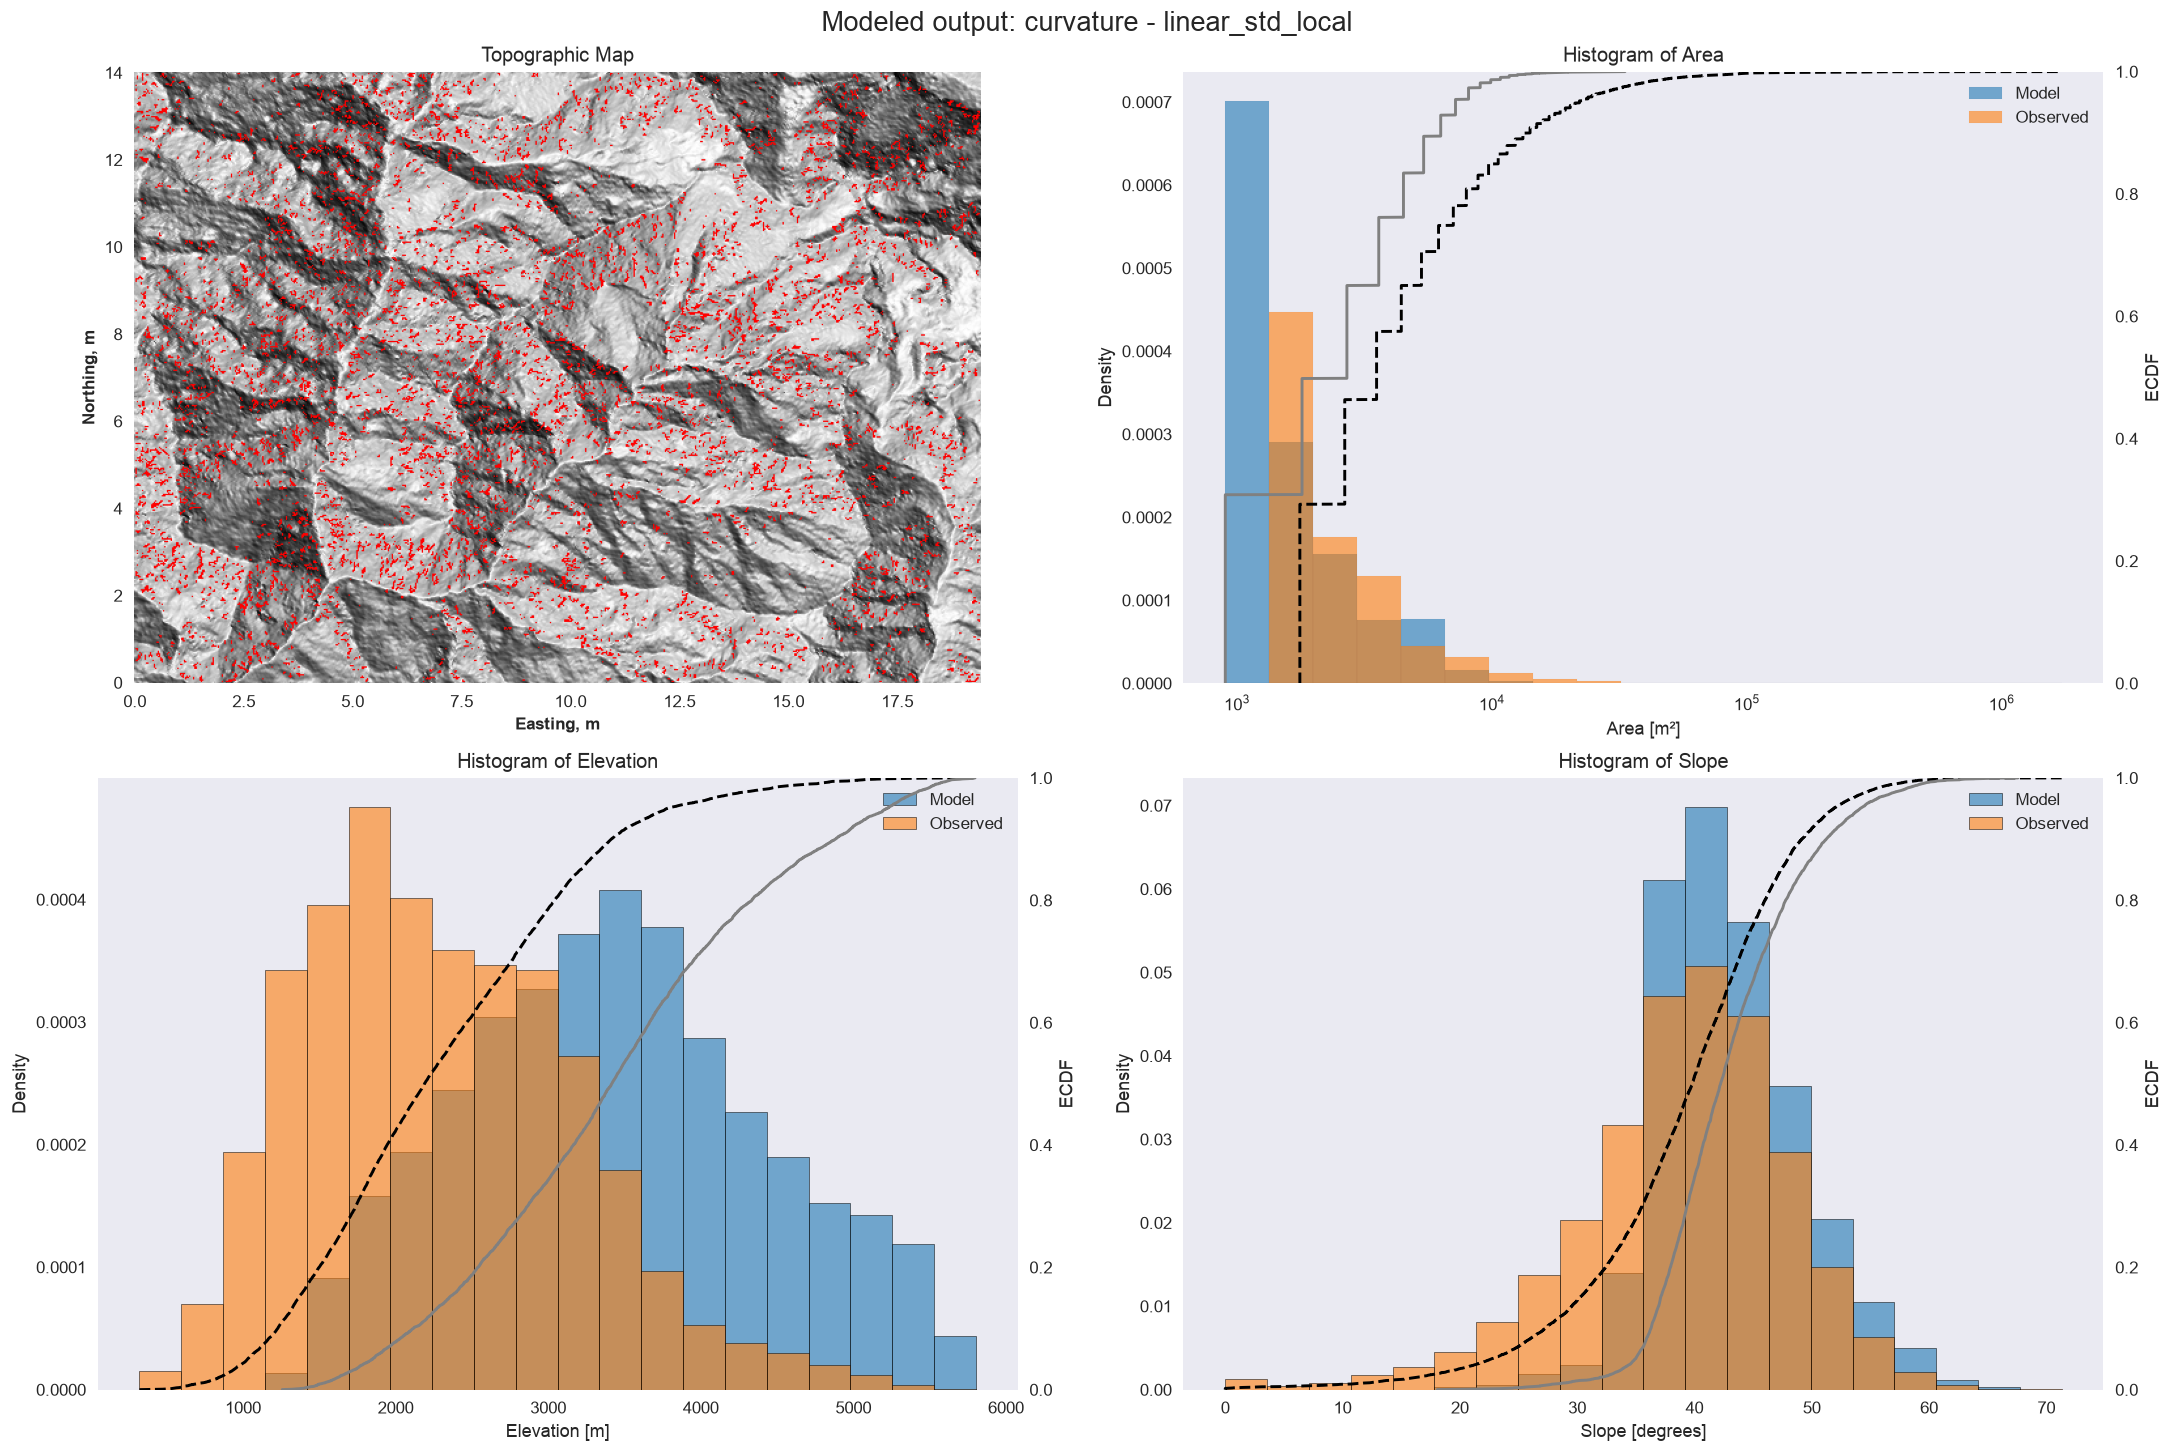

In [21]:
plot_comparison_panels_with_ecdf(
    observed_df=measured_spatial_stats_900greater,
    model_df=props_filtered,
    mg=mg,                     # optional
    labels_masked=labels_masked,  # optional
    title=f"Modeled output: {config['soil_params']['distribution']} - {config['soil_params']['relationship']}",
    save_path=None             # or "comparison_panels.pdf"
)

## Hand the run to the output-analysis workflow
The saved directory is loaded here using the same API as `ShallowLandslider_output_analysis.ipynb`. After this check, open that notebook and run all cells; its default `RUNS_ROOT = Path("runs")` will discover this run.

In [22]:
from analysis import load_run

if run_dir is None:
    print('Saving was disabled; set save_analysis_bundle=True and rerun the model cell.')
else:
    saved_run = load_run(run_dir, load_rasters=True)
    print('Analysis loader opened:', saved_run['path'])
    display(saved_run['regions'].head())


Analysis loader opened: runs/20260804T102405585485Z_SL_c15000_phi30_sub50_curvature-linear_std_local_probabilistic_seed5000


,run_id,label,max_elevation,median_elevation,area,slope_direction_length_new,perpendicular_width_new,local_relief,median_slope,mean_aspect,...,mean_critical_acceleration,mean_a_diff,max_newmark_displacement,cohesion_eff,angle_int_frict,submerged_soil_proportion,soil_distribution,soil_relationship,selection_method,random_seed
0,20260804T102405585485Z_SL_c15000_phi30_sub50_c...,1,1504.0,1483.0,2700.0,60.000000,0.000000,41.0,31.212049,119.557037,...,2.392002,1.516017,NaN,15000.0,30,0.5,curvature,linear_std_local,probabilistic,5000
1,20260804T102405585485Z_SL_c15000_phi30_sub50_c...,2,1781.0,1761.0,3600.0,67.082039,26.832816,40.0,31.700397,30.104026,...,1.440151,2.459336,NaN,15000.0,30,0.5,curvature,linear_std_local,probabilistic,5000
2,20260804T102405585485Z_SL_c15000_phi30_sub50_c...,3,1763.0,1732.0,7200.0,90.000000,90.000000,55.0,29.963266,60.468001,...,2.337054,1.806646,NaN,15000.0,30,0.5,curvature,linear_std_local,probabilistic,5000
3,20260804T102405585485Z_SL_c15000_phi30_sub50_c...,4,1841.0,1823.0,8100.0,107.331263,107.331263,41.0,24.614113,40.458158,...,3.353104,1.091592,NaN,15000.0,30,0.5,curvature,linear_std_local,probabilistic,5000
4,20260804T102405585485Z_SL_c15000_phi30_sub50_c...,5,1695.0,1644.0,7200.0,123.693169,50.932481,75.0,31.464355,27.999918,...,1.800845,2.187224,NaN,15000.0,30,0.5,curvature,linear_std_local,probabilistic,5000


In [ ]:
if run_dir is not None:
    saved_rasters = saved_run['rasters']
    saved_fields = (
        list(saved_rasters.data_vars)
        if hasattr(saved_rasters, 'data_vars')
        else list(saved_rasters)
    )
    print('Saved raster fields:')
    print(', '.join(saved_fields))
    expected_runout = {'runout_erosion', 'runout_deposition', 'runout_soil_depth_change'}
    print('Runout rasters available:', expected_runout.issubset(saved_fields))


In [ ]:
if run_dir is not None:
    print('Next: open ShallowLandslider_output_analysis.ipynb and run all cells.')
    print(f'It will discover this run below: {Path(config["output"]["output_dir"]).resolve()}')


## Troubleshooting & Tips

- **Field names** follow the Landlab convention used in the component (e.g., `topographic__elevation`, `soil__depth`).
- If you see a `ValueError` about sizes, ensure arrays match `mg.number_of_nodes`.
- The public notebook uses a bundled DEM by default. To download a fresh DEM, set `use_local_dem=False` and provide `OPENTOPOGRAPHY_API_KEY` in your environment.
- Use `selection_method='pga_weighted'` for a deterministic proportion based on PGA; otherwise keep `'probabilistic'`.
- Turn on `compute_displacement=True` to write `landslide__newmark_displacement`.
- For runout, keep `flow_params.separate_hill_flow=True`, use a multiflow `hill_flow_metric` such as `Quinn`, and set `compute_displacement=True`, `enable_runout=True`, and `update_soil=True`.
- Set `aspect_interval` to a coarser (e.g., 45°) if too many subgroups are created.
- For reproducibility, set `random_seed`.
- For very small regions, consider post‑processing with `handle_small_regions` in your helper functions or merge/keep logic.

> For performance on large domains, start with smaller extents and lower `smooth_num`, and avoid plotting huge arrays.
